# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import os
import warnings
import kagglehub
from kagglehub import KaggleDatasetAdapter
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [5]:
file_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "blastchar/telco-customer-churn",
  file_path,
)

df.head()

Using Colab cache for faster access to the 'telco-customer-churn' dataset.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [13]:
# ── 4.1 Info & tipe data ──────────────────────────────────────────
print(df.info())
print("\nStatistik deskriptif:")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [14]:
# ── 4.2 Missing values ───────────────────────────────────────────
print("Missing values per kolom:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per kolom:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total missing: 0


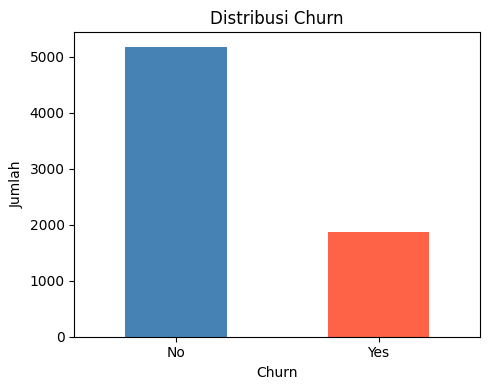

In [15]:
# ── 4.3 Distribusi target (Churn) ────────────────────────────────
plt.figure(figsize=(5, 4))
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Distribusi Churn')
plt.xlabel('Churn')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('eda_churn_distribution.png')
plt.show()

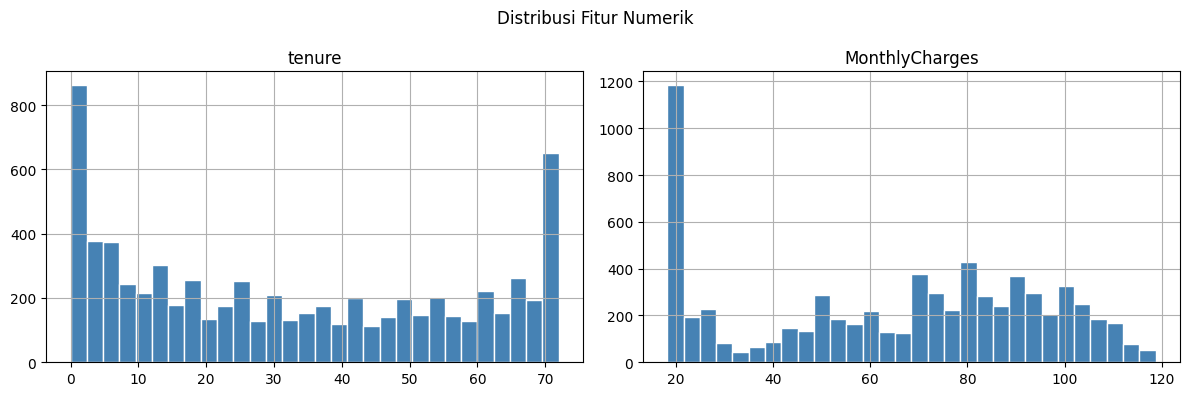

In [16]:
# ── 4.4 Distribusi fitur numerik ─────────────────────────────────
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[num_cols].hist(bins=30, figsize=(12, 4), color='steelblue', edgecolor='white')
plt.suptitle('Distribusi Fitur Numerik')
plt.tight_layout()
plt.savefig('eda_numeric_distribution.png')
plt.show()

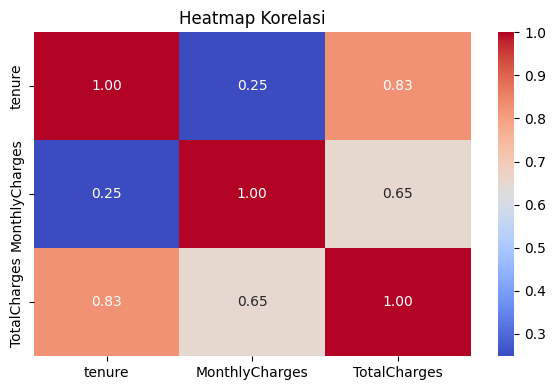

In [17]:
# ── 4.5 Korelasi fitur numerik ───────────────────────────────────
# Create a temporary DataFrame for correlation calculation to avoid modifying the global df prematurely
df_corr = df.copy()

# Convert 'TotalCharges' column to numeric, replacing ' ' with NaN
df_corr['TotalCharges'] = pd.to_numeric(df_corr['TotalCharges'], errors='coerce')

# Fill NaN values (which originated from ' ' in 'TotalCharges') with 0.
# This is a common approach for new customers with 0 tenure and thus 0 total charges.
df_corr['TotalCharges'].fillna(0, inplace=True)

plt.figure(figsize=(6, 4))
sns.heatmap(df_corr[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [18]:
# ── 5.1 Fix TotalCharges: konversi object → numeric ──────────────
# Spasi kosong " " akan jadi NaN setelah to_numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

missing_after = df['TotalCharges'].isnull().sum()
print(f"Hidden missing di TotalCharges: {missing_after} baris")

# Lihat baris yang bermasalah
df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'TotalCharges']].head()

Hidden missing di TotalCharges: 11 baris


,customerID,tenure,TotalCharges
488,4472-LVYGI,0,NaN
753,3115-CZMZD,0,NaN
936,5709-LVOEQ,0,NaN
1082,4367-NUYAO,0,NaN
1340,1371-DWPAZ,0,NaN


In [19]:
# ── 5.2 Handle missing TotalCharges ──────────────────────────────
# Baris dengan tenure=0 wajar TotalCharges-nya 0
df['TotalCharges'].fillna(0, inplace=True)
print("Missing setelah fix:", df['TotalCharges'].isnull().sum())

Missing setelah fix: 0


In [20]:
# ── 5.3 Drop kolom tidak relevan ─────────────────────────────────
df.drop(columns=['customerID'], inplace=True)
print("customerID di-drop. Shape:", df.shape)

customerID di-drop. Shape: (7043, 20)


In [21]:
# ── 5.4 Encoding kolom biner (Yes/No & Male/Female) ──────────────
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'Churn']

for col in binary_cols:
    df[col] = df[col].map(binary_map)

print("Binary encoding selesai.")

Binary encoding selesai.


In [22]:
# ── 5.5 One-Hot Encoding kolom multi-kategori ────────────────────
# Kolom ini punya 3+ nilai unik termasuk "No internet service" dll
multi_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod'
]
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)
print("Shape setelah OHE:", df.shape)

Shape setelah OHE: (7043, 31)


In [23]:
# ── 5.6 Scaling fitur numerik ────────────────────────────────────
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[num_cols] = scaler.fit_transform(df[num_cols])

print("Scaling selesai. Sample:")
df[num_cols].describe().round(2)

Scaling selesai. Sample:


,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00
mean,-0.00,-0.00,-0.00
std,1.00,1.00,1.00
min,-1.32,-1.55,-1.01
25%,-0.95,-0.97,-0.83
50%,-0.14,0.19,-0.39
75%,0.92,0.83,0.66
max,1.61,1.79,2.83


In [24]:
# ── 5.7 Handle class imbalance dengan SMOTE ───────────────────────
# Churn: No ~73% vs Yes ~27% → imbalanced, perlu di-oversample
from imblearn.over_sampling import SMOTE

X = df.drop(columns=['Churn'])
y = df['Churn']

print("Sebelum SMOTE:", y.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Setelah SMOTE:", pd.Series(y_resampled).value_counts().to_dict())

Sebelum SMOTE: {0: 5174, 1: 1869}
Setelah SMOTE: {0: 5174, 1: 5174}


In [25]:
# ── 5.8 Train-test split & simpan hasil ──────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2, random_state=42, stratify=y_resampled
)

import os
os.makedirs('telco_preprocessing', exist_ok=True)

X_train.to_csv('telco_preprocessing/X_train.csv', index=False)
X_test.to_csv('telco_preprocessing/X_test.csv', index=False)
y_train.to_csv('telco_preprocessing/y_train.csv', index=False)
y_test.to_csv('telco_preprocessing/y_test.csv', index=False)

print("✅ Preprocessing selesai!")
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

✅ Preprocessing selesai!
X_train: (8278, 30) | X_test: (2070, 30)
